# **Step 0**

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torch-geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
!pip install scanpy anndata numpy pandas scipy scikit-learn matplotlib seaborn tqdm
!pip install leidenalg
!pip install scvi-tools igraph  leidenalg
from google.colab import drive
drive.mount('/content/drive')


In [106]:
import pandas as pd
import numpy as np
import glob
import os
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
import torch.nn.functional as F
import torch.nn as nn
import shlex



from torch_geometric.nn import SAGEConv, BatchNorm
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.loader import GraphSAINTRandomWalkSampler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix
)
from sklearn.manifold import TSNE
from scipy.sparse import issparse
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from tqdm import tqdm
from torch_geometric.nn import GCNConv, GATConv
from sklearn.model_selection import train_test_split



# **Step 1** - download files and maerge them

In [107]:

meta_path = "/content/drive/MyDrive/state_project/data/intermediate/GSE174554_Tumor_normal_metadata.txt"

meta = pd.read_csv(meta_path, sep=r"\s+", engine="python", header=0)

print("Columns:", meta.columns.tolist())
print(meta.head())

meta['sample_id'] = meta['Sample#_Barcode'].apply(lambda x: x.split("_")[0])
meta['barcode']   = meta['Sample#_Barcode'].apply(lambda x: x.split("_")[1])

meta.head()


Columns: ['Sample#_Barcode', 'Tumor_Normal_annotation']
            Sample#_Barcode Tumor_Normal_annotation
0  SF10022_CTATCTAAGCAAGCCA                   Tumor
1  SF10022_AAACCCAGTCTACGAT                  Normal
2  SF10022_AAAGGGCTCACCCTGT                  Normal
3  SF10022_AACAACCAGACCCGCT                  Normal
4  SF10022_AACAAGAGTGTAAACA                  Normal


,Sample#_Barcode,Tumor_Normal_annotation,sample_id,barcode
0,SF10022_CTATCTAAGCAAGCCA,Tumor,SF10022,CTATCTAAGCAAGCCA
1,SF10022_AAACCCAGTCTACGAT,Normal,SF10022,AAACCCAGTCTACGAT
2,SF10022_AAAGGGCTCACCCTGT,Normal,SF10022,AAAGGGCTCACCCTGT
3,SF10022_AACAACCAGACCCGCT,Normal,SF10022,AACAACCAGACCCGCT
4,SF10022_AACAAGAGTGTAAACA,Normal,SF10022,AACAAGAGTGTAAACA


In [108]:

test_feat = "/content/drive/MyDrive/state_project/data/raw/GSE174554_RAW/GSM5319503_SF10099_features.tsv.gz"

df = pd.read_csv(test_feat, sep="\t", header=None)
print(df.head())
print(df.shape)


              0
0  RP11-34P13.3
1       FAM138A
2         OR4F5
3  RP11-34P13.7
4  RP11-34P13.8
(33694, 1)


In [109]:

raw_dir = "/content/drive/MyDrive/state_project/data/raw/GSE174554_RAW/"
files = os.listdir(raw_dir)
BAD_SAMPLES = {
    "SF8963",
}
BAD_BATCHES = {
    "SF4810_2",
}
sample_ids = sorted(list({
    f.split("_")[1]
    for f in files
    if f.endswith("barcodes.tsv.gz")
}))
adata_list = []
skipped = []

def load_one(bar, feat, mtx, sample_id, batch_id):
    try:
        ad = sc.read_mtx(mtx).T
        feat_df = pd.read_csv(feat, sep="\t", header=None)
        genes = feat_df[0].astype(str).values
        bar_df = pd.read_csv(bar, sep="\t", header=None)
        barcodes = bar_df[0].astype(str).values
        if ad.shape[1] != len(genes):
            print(f"Gene mismatch → skipping {sample_id} batch {batch_id}")
            return None

        if ad.shape[0] != len(barcodes):
            print(f"Barcode mismatch → skipping {sample_id} batch {batch_id}")
            return None
        ad.var_names = genes
        ad.obs_names = [f"{sample_id}_{b}" for b in barcodes]

        ad.obs["sample_id"] = sample_id
        ad.obs["batch"] = batch_id

        return ad

    except Exception as e:
        print(f"Error loading {sample_id} batch {batch_id}: {e}")
        return None



for sample in tqdm(sample_ids):
    if sample in BAD_SAMPLES:
        print(f"Skipping entire sample: {sample}")
        skipped.append(f"{sample} (all)")
        continue

    b1_bar = glob.glob(f"{raw_dir}/GSM*_{sample}_barcodes.tsv.gz")
    b1_feat = glob.glob(f"{raw_dir}/GSM*_{sample}_features.tsv.gz")
    b1_mtx  = glob.glob(f"{raw_dir}/GSM*_{sample}_matrix.mtx.gz")

    b2_bar = glob.glob(f"{raw_dir}/GSM*_{sample}_batch2_barcodes.tsv.gz")
    b2_feat = glob.glob(f"{raw_dir}/GSM*_{sample}_batch2_features.tsv.gz")
    b2_mtx  = glob.glob(f"{raw_dir}/GSM*_{sample}_batch2_matrix.mtx.gz")

    if b1_bar and b1_feat and b1_mtx:
        batch_id = 1
        if f"{sample}_{batch_id}" in BAD_BATCHES:
            print(f"Skipping {sample} batch1 (blocked manually)")
            skipped.append(f"{sample}_batch1")
        else:
            ad = load_one(b1_bar[0], b1_feat[0], b1_mtx[0], sample, batch_id)
            if ad is not None:
                adata_list.append(ad)
            else:
                skipped.append(f"{sample}_batch1")

    if b2_bar and b2_feat and b2_mtx:
        batch_id = 2
        if f"{sample}_{batch_id}" in BAD_BATCHES:
            print(f"Skipping {sample} batch2 (blocked manually)")
            skipped.append(f"{sample}_batch2")
        else:
            ad = load_one(b2_bar[0], b2_feat[0], b2_mtx[0], sample, batch_id)
            if ad is not None:
                adata_list.append(ad)
            else:
                skipped.append(f"{sample}_batch2")

print("\n========== SUMMARY ==========")
print("Loaded:", len(adata_list))
print("Skipped:", skipped)
print("================================\n")


 71%|███████   | 60/85 [00:52<00:15,  1.58it/s]

⛔ Skipping SF4810 batch2 (blocked manually)


 86%|████████▌ | 73/85 [00:59<00:08,  1.36it/s]

⛔ Skipping entire sample: SF8963


100%|██████████| 85/85 [01:09<00:00,  1.23it/s]


========== SUMMARY ==========
Loaded: 89
Skipped: ['SF4810_batch2', 'SF8963 (all)']



In [110]:
adata = adata_list[0].concatenate(adata_list[1:], batch_key="patient_batch")
adata


/tmp/ipython-input-2472581799.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_list[0].concatenate(adata_list[1:], batch_key="patient_batch")


AnnData object with n_obs × n_vars = 224685 × 33694
    obs: 'sample_id', 'batch', 'patient_batch'

# **Step 2** - get labels

In [111]:

meta_path = "/content/drive/MyDrive/state_project/data/intermediate/GSE174554_Tumor_normal_metadata.txt"

meta = pd.read_csv(meta_path, sep=r"\s+", engine="python", header=0)

meta['sample_id'] = meta['Sample#_Barcode'].apply(lambda x: x.split("_")[0])
meta['barcode']   = meta['Sample#_Barcode'].apply(lambda x: x.split("_")[1])

print(meta.head())
print(meta.shape)


            Sample#_Barcode Tumor_Normal_annotation sample_id  \
0  SF10022_CTATCTAAGCAAGCCA                   Tumor   SF10022   
1  SF10022_AAACCCAGTCTACGAT                  Normal   SF10022   
2  SF10022_AAAGGGCTCACCCTGT                  Normal   SF10022   
3  SF10022_AACAACCAGACCCGCT                  Normal   SF10022   
4  SF10022_AACAAGAGTGTAAACA                  Normal   SF10022   

            barcode  
0  CTATCTAAGCAAGCCA  
1  AAACCCAGTCTACGAT  
2  AAAGGGCTCACCCTGT  
3  AACAACCAGACCCGCT  
4  AACAAGAGTGTAAACA  
(254288, 4)


In [112]:
adata.obs["barcode"] = adata.obs_names
adata.obs["sample_id"] = adata.obs["sample_id"].astype(str)

adata.obs = adata.obs.merge(
    meta[["sample_id", "barcode", "Tumor_Normal_annotation"]],
    on=["sample_id", "barcode"],
    how="left"
)

print("Missing tumor/normal labels:", adata.obs["Tumor_Normal_annotation"].isna().sum())


Missing tumor/normal labels: 224685


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [113]:
adata = adata[adata.obs["Tumor_Normal_annotation"].notna()].copy()


In [114]:
adata = adata_list[0].concatenate(adata_list[1:], batch_key="patient_batch")


/tmp/ipython-input-3520309324.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_list[0].concatenate(adata_list[1:], batch_key="patient_batch")


# **Step 3** - filtering and pre-prossing

In [115]:

adata = ad.concat(
    adata_list,
    join="outer",
    label="patient_batch",
    keys=list(range(len(adata_list)))
)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [116]:
sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=5)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/lib/pyth

In [117]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")


In [118]:


sp_path = "/content/drive/MyDrive/state_project/data/intermediate/GSE174554_Spatial_transcriptomic_matrix.txt"

rows = []
with open(sp_path, "r") as f:
    for line in f:
        tokens = shlex.split(line.strip())
        rows.append(tokens)

sp_df = pd.DataFrame(rows)
spot_ids = sp_df.iloc[0, 1:]
spot_ids = spot_ids.str.replace('"', '', regex=False)
gene_names = sp_df.iloc[1:, 0].str.replace('"', '', regex=False)
expr = sp_df.iloc[1:, 1:].astype(float)
expr.index = gene_names
expr.columns = spot_ids
sp_adata = sc.AnnData(expr.T)



/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [119]:


sp_path = "/content/drive/MyDrive/state_project/data/intermediate/GSE174554_Spatial_transcriptomic_matrix.txt"

rows = []
with open(sp_path, "r") as f:
    for line in f:
        tokens = shlex.split(line.strip())
        rows.append(tokens)

sp_df = pd.DataFrame(rows)
spot_ids = sp_df.iloc[0, 1:].str.replace('"', '', regex=False)
gene_names = sp_df.iloc[1:, 0].str.replace('"', '', regex=False)
expr = sp_df.iloc[1:, 1:].astype(float)
expr.index = gene_names
expr.columns = spot_ids

print(expr.shape)


(1825, 118)


In [120]:

sp_adata = sc.AnnData(expr.T)


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [121]:
sc.pp.normalize_total(sp_adata)
sc.pp.log1p(sp_adata)
sc.pp.highly_variable_genes(sp_adata, n_top_genes=2000)
sp_adata = sp_adata[:, sp_adata.var.highly_variable]

sc.pp.scale(sp_adata, max_value=10)
sc.tl.pca(sp_adata, n_comps=50)
sc.pp.neighbors(sp_adata)
sc.tl.umap(sp_adata)

sp_adata.obs["x"] = sp_adata.obsm["X_umap"][:,0]
sp_adata.obs["y"] = sp_adata.obsm["X_umap"][:,1]


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


# **Step 4** - build graphs

In [122]:
sc.pp.neighbors(sp_adata, n_neighbors=10, n_pcs=30)

row, col = sp_adata.obsp["connectivities"].nonzero()
edges_sp = np.vstack([row, col])

print("Spatial graph edges:", edges_sp.shape)


Spatial graph edges: (2, 1422)


In [123]:
coords = sp_adata.obsm["spatial"] if "spatial" in sp_adata.obsm else sp_adata.obs[["x", "y"]].values

expr = sp_adata.X.toarray() if not isinstance(sp_adata.X, np.ndarray) else sp_adata.X

ccc_data = {
    "expression": expr,
    "coordinates": coords,
    "edges": edges_sp,
    "gene_names": np.array(sp_adata.var_names)
}

print("CCC prep complete:", {k: v.shape if hasattr(v, 'shape') else len(v) for k,v in ccc_data.items() if isinstance(v, (np.ndarray, list))})


CCC prep complete: {'expression': (118, 1825), 'coordinates': (118, 2), 'edges': (2, 1422), 'gene_names': (1825,)}


In [124]:


X_raw = sp_adata.X
if issparse(X_raw):
    X = torch.tensor(X_raw.toarray(), dtype=torch.float32)
else:
    X = torch.tensor(np.array(X_raw), dtype=torch.float32)

row, col = sp_adata.obsp["connectivities"].nonzero()
edge_index = torch.tensor(np.vstack([row, col]), dtype=torch.long)

coords = (
    sp_adata.obsm["spatial"]
    if "spatial" in sp_adata.obsm
    else sp_adata.obs[["x", "y"]].values
)
pos = torch.tensor(coords, dtype=torch.float32)

spatial_graph = Data(
    x=X,
    edge_index=edge_index,
    pos=pos
)

print(spatial_graph)


Data(x=[118, 1825], edge_index=[2, 1422], pos=[118, 2])


In [125]:
def build_spatial_graph(adata):
    import numpy as np
    import torch
    from torch_geometric.data import Data
    from scipy.sparse import issparse
    import scanpy as sc

    sc.pp.neighbors(adata, n_neighbors=10)

    row, col = adata.obsp["connectivities"].nonzero()
    edge_index = torch.tensor(np.vstack([row, col]), dtype=torch.long)

    X_raw = adata.X
    X = torch.tensor(X_raw.toarray() if issparse(X_raw) else np.array(X_raw), dtype=torch.float32)

    coords = (
        adata.obsm["spatial"]
        if "spatial" in adata.obsm
        else adata.obs[["x", "y"]].values
    )
    pos = torch.tensor(coords, dtype=torch.float32)

    return Data(x=X, edge_index=edge_index, pos=pos)

spatial_graph = build_spatial_graph(sp_adata)


# **Step 2b** - fix some issues with labels

In [126]:
meta_path = "/content/drive/MyDrive/state_project/data/intermediate/GSE174554_Tumor_normal_metadata.txt"
meta = pd.read_csv(meta_path, sep=r"\s+", engine="python")

meta["sample_id"] = meta["Sample#_Barcode"].apply(lambda x: x.split("_")[0])
meta["barcode"]    = meta["Sample#_Barcode"].apply(lambda x: x.split("_")[1])

print(meta.head())


            Sample#_Barcode Tumor_Normal_annotation sample_id  \
0  SF10022_CTATCTAAGCAAGCCA                   Tumor   SF10022   
1  SF10022_AAACCCAGTCTACGAT                  Normal   SF10022   
2  SF10022_AAAGGGCTCACCCTGT                  Normal   SF10022   
3  SF10022_AACAACCAGACCCGCT                  Normal   SF10022   
4  SF10022_AACAAGAGTGTAAACA                  Normal   SF10022   

            barcode  
0  CTATCTAAGCAAGCCA  
1  AAACCCAGTCTACGAT  
2  AAAGGGCTCACCCTGT  
3  AACAACCAGACCCGCT  
4  AACAAGAGTGTAAACA  


In [127]:
sample_to_label = meta.set_index("sample_id")["Tumor_Normal_annotation"].to_dict()

adata.obs["Tumor_Normal_annotation"] = adata.obs["sample_id"].map(sample_to_label)

print("Missing labels:", adata.obs["Tumor_Normal_annotation"].isna().sum())
valid_samples = set(meta["sample_id"])
adata = adata[adata.obs["sample_id"].isin(valid_samples)].copy()



Missing labels: 27223


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [128]:
tumor_labels_sn = (adata.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values


In [129]:
sp_adata.obs["sample_id"] = sp_adata.obs_names.to_series().str.rsplit(pat="_", n=1, expand=True)[0]
tumor_map = meta.groupby("sample_id")["Tumor_Normal_annotation"].first().to_dict()
import re

def normalize_spatial_id(x):
    match = re.match(r"(SF\d+)", x)
    return match.group(1) if match else x

sp_adata.obs["base_id"] = sp_adata.obs["sample_id"].apply(normalize_spatial_id)
sp_adata.obs["Tumor_Normal_annotation"] = (
    sp_adata.obs["base_id"].map(tumor_map).fillna("Unknown")
)
tumor_labels_sp = (sp_adata.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values
print(sp_adata.obs["Tumor_Normal_annotation"].value_counts())
print("Tumor labels vector shape:", tumor_labels_sp.shape)

keep_mask = sp_adata.obs["Tumor_Normal_annotation"].isin(["Tumor", "Normal"])
sp_adata_clean = sp_adata[keep_mask].copy()

print("Remaining spots:", sp_adata_clean.n_obs)
print(sp_adata_clean.obs["Tumor_Normal_annotation"].value_counts())



Tumor_Normal_annotation
Normal     80
Unknown    22
Tumor      16
Name: count, dtype: int64
Tumor labels vector shape: (118,)
Remaining spots: 96
Tumor_Normal_annotation
Normal    80
Tumor     16
Name: count, dtype: int64


In [130]:
tumor_labels_sp = (sp_adata_clean.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values


# **step 5** - fix the data issues with cuda memory

In [131]:
def make_splits(labels, test_size=0.2, val_size=0.1):
    idx = np.arange(len(labels))

    train_idx, test_idx = train_test_split(
        idx, test_size=test_size, stratify=labels, random_state=42
    )

    train_idx, val_idx = train_test_split(
        train_idx, test_size=val_size, stratify=labels[train_idx], random_state=42
    )

    return (
        torch.tensor(train_idx, dtype=torch.long),
        torch.tensor(val_idx, dtype=torch.long),
        torch.tensor(test_idx, dtype=torch.long)
    )


In [132]:
if "X_pca" not in adata.obsm:
    print("Running PCA for snRNA...")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable]
    sc.pp.scale(adata)
    sc.tl.pca(adata, n_comps=50)

print("Building neighbor graph...")
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")

row, col = adata.obsp["connectivities"].nonzero()
edge_index_sn = torch.tensor(np.vstack([row, col]), dtype=torch.long)

X_raw = adata.X
if issparse(X_raw):
    X_sn = torch.tensor(X_raw.toarray(), dtype=torch.float32)
else:
    X_sn = torch.tensor(np.array(X_raw), dtype=torch.float32)

snrna_graph = Data(
    x=X_sn,
    edge_index=edge_index_sn
)

print("snRNA graph:", snrna_graph)


Building neighbor graph...
snRNA graph: Data(x=[187850, 3000], edge_index=[2, 2767160])


In [133]:
sc.pp.neighbors(sp_adata, n_neighbors=10)

row, col = sp_adata.obsp["connectivities"].nonzero()
edges_sp = np.vstack([row, col])

edge_index_sp = torch.tensor(edges_sp, dtype=torch.long)

X_raw_sp = sp_adata.X
X_sp = torch.tensor(X_raw_sp.toarray() if issparse(X_raw_sp) else np.array(X_raw_sp), dtype=torch.float32)

coords_sp = (
    sp_adata.obsm["spatial"]
    if "spatial" in sp_adata.obsm
    else sp_adata.obs[["x", "y"]].values
)
pos_sp = torch.tensor(coords_sp, dtype=torch.float32)

spatial_graph = Data(
    x=X_sp,
    edge_index=edge_index_sp,
    pos=pos_sp
)

print("Spatial graph:", spatial_graph)


Spatial graph: Data(x=[118, 1825], edge_index=[2, 1462], pos=[118, 2])


In [134]:
tumor_labels_sn = (adata.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values
print("snRNA tumor label shape:", tumor_labels_sn.shape)
tumor_labels_sp = (sp_adata_clean.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values
print("Spatial tumor label shape:", tumor_labels_sp.shape)


snRNA tumor label shape: (187850,)
Spatial tumor label shape: (96,)


In [136]:
tumor_labels_sp_fixed = np.zeros(spatial_graph.num_nodes, dtype=int)
tumor_labels_sp_fixed[:len(tumor_labels_sp)] = tumor_labels_sp

if "X_pca" not in adata.obsm:
    print("Running PCA for snRNA...")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable]
    sc.pp.scale(adata)
    sc.tl.pca(adata, n_comps=50)

print("Building neighbor graph...")
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")

row, col = adata.obsp["connectivities"].nonzero()
edge_index_sn = torch.tensor(np.vstack([row, col]), dtype=torch.long)

X_sn = torch.tensor(adata.obsm["X_pca"], dtype=torch.float32)

snrna_graph = Data(
    x=X_sn,
    edge_index=edge_index_sn
)

print("snRNA graph:", snrna_graph)


Building neighbor graph...
snRNA graph: Data(x=[187850, 50], edge_index=[2, 2767160])


In [137]:

sc.pp.neighbors(sp_adata, n_neighbors=10)

row, col = sp_adata.obsp["connectivities"].nonzero()
edges_sp = np.vstack([row, col])

edge_index_sp = torch.tensor(edges_sp, dtype=torch.long)

X_raw_sp = sp_adata.X
X_sp = torch.tensor(X_raw_sp.toarray() if issparse(X_raw_sp) else np.array(X_raw_sp), dtype=torch.float32)

coords_sp = (
    sp_adata.obsm["spatial"]
    if "spatial" in sp_adata.obsm
    else sp_adata.obs[["x", "y"]].values
)
pos_sp = torch.tensor(coords_sp, dtype=torch.float32)

spatial_graph = Data(
    x=X_sp,
    edge_index=edge_index_sp,
    pos=pos_sp
)

print("Spatial graph:", spatial_graph)


Spatial graph: Data(x=[118, 1825], edge_index=[2, 1462], pos=[118, 2])


In [138]:
def patient_split(patient_ids, train_frac=0.8):
    unique_patients = np.unique(patient_ids)
    np.random.seed(42)

    train_patients = np.random.choice(unique_patients,
                                      size=int(len(unique_patients)*train_frac),
                                      replace=False)

    test_patients = np.setdiff1d(unique_patients, train_patients)

    train_mask = np.isin(patient_ids, train_patients)
    test_mask  = np.isin(patient_ids, test_patients)

    return train_mask, test_mask, train_patients, test_patients
tumor_labels_sp_fixed = np.zeros(spatial_graph.num_nodes, dtype=int)

tumor_labels_sp_fixed[:len(tumor_labels_sp)] = tumor_labels_sp


In [156]:

valid = sp_adata.obs["Tumor_Normal_annotation"] != "Unknown"
sp_adata = sp_adata[valid].copy()

sc.pp.neighbors(sp_adata, n_neighbors=10)

row, col = sp_adata.obsp["connectivities"].nonzero()
edge_index_sp = torch.tensor(np.vstack([row, col]), dtype=torch.long)

X_raw = sp_adata.X
X_sp = torch.tensor(X_raw.toarray() if issparse(X_raw) else np.array(X_raw), dtype=torch.float32)

coords = (
    sp_adata.obsm["spatial"]
    if "spatial" in sp_adata.obsm
    else sp_adata.obs[["x", "y"]].values
)
pos_sp = torch.tensor(coords, dtype=torch.float32)

spatial_graph = Data(
    x=X_sp,
    edge_index=edge_index_sp,
    pos=pos_sp
)

print("NEW SPATIAL GRAPH:", spatial_graph)
tumor_labels_sp = (sp_adata.obs["Tumor_Normal_annotation"] == "Tumor").astype(int).values
print(len(tumor_labels_sp))
N_sp = spatial_graph.num_nodes

idx = np.arange(N_sp)
np.random.shuffle(idx)

train_count = int(0.6 * N_sp)
test_count  = int(0.2 * N_sp)

sp_train_mask = torch.zeros(N_sp, dtype=torch.bool)
sp_test_mask  = torch.zeros(N_sp, dtype=torch.bool)

sp_train_mask[idx[:train_count]] = True
sp_test_mask[idx[train_count:train_count+test_count]] = True



NEW SPATIAL GRAPH: Data(x=[96, 1825], edge_index=[2, 1196], pos=[96, 2])
96


# **Step 6**  - build the model and test it 60-20-20

In [139]:
if hasattr(spatial_graph, "pos"):
    spatial_graph.x = torch.cat([spatial_graph.x, spatial_graph.pos], dim=1)


In [140]:
def make_masks(n):
    idx = np.random.permutation(n)
    n_train = int(n * 0.6)
    n_val = int(n * 0.2)

    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)

    train_mask[idx[:n_train]] = True
    val_mask[idx[n_train:n_train+n_val]] = True
    test_mask[idx[n_train+n_val:]] = True

    return train_mask, val_mask, test_mask

sn_train_mask, sn_test_mask = build_masks(snrna_graph.num_nodes)
sp_train_mask, sp_test_mask = build_masks(spatial_graph.num_nodes)


In [141]:
class ImprovedGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, heads=2, dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=dropout)

        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.gat2(x, edge_index)
        x = F.elu(x)

        x = self.dropout(x)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.lin2(x)
        return x



In [163]:
def train_gnn(
    graph,
    labels,
    train_mask,
    test_mask,
    num_classes=2,
    max_epochs=50,
    lr=1e-3,
):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    labels = torch.tensor(labels, dtype=torch.long)

    N = graph.num_nodes
    in_dim = graph.x.shape[1]

    model = ImprovedGNN(
        in_dim=in_dim,
        hidden_dim=64,
        num_classes=num_classes,
        heads=2,
        dropout=0.3
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    history = {"epoch": [], "train_loss": [], "test_acc": []}

    if N > 50000:
        print(f"[train_gnn] Using NeighborLoader mini-batch training for {N} nodes.")

        train_loader = GraphSAINTRandomWalkSampler(
          graph,
          batch_size=2000,
          walk_length=2,
          num_steps=40,
          sample_coverage=0,
        )

        test_loader = GraphSAINTRandomWalkSampler(
            graph,
            batch_size=2000,
            walk_length=2,
            num_steps=10,
            sample_coverage=0,
        )

        for epoch in range(1, max_epochs + 1):
            model.train()
            total_loss = 0.0
            total_nodes = 0

            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()

                out = model(batch.x, batch.edge_index)

                y_batch = labels[batch.n_id].to(device)

                loss = F.cross_entropy(out, y_batch)
                loss.backward()
                optimizer.step()

                total_loss += loss.item() * batch.num_nodes
                total_nodes += batch.num_nodes

            avg_loss = total_loss / max(total_nodes, 1)

            model.eval()
            correct = 0
            total = 0

            with torch.no_grad():
                for batch in test_loader:
                    batch = batch.to(device)
                    out = model(batch.x, batch.edge_index)
                    pred = out.argmax(dim=-1).cpu()
                    y_batch = labels[batch.n_id].cpu()
                    correct += (pred == y_batch).sum().item()
                    total += len(y_batch)

            test_acc = correct / total if total > 0 else 0.0

            if epoch == 1 or epoch % 5 == 0:
                print(
                    f"Epoch {epoch}/{max_epochs} | "
                    f"Train Loss = {avg_loss:.4f} | Test Acc = {test_acc:.4f}"
                )

            history["epoch"].append(epoch)
            history["train_loss"].append(avg_loss)
            history["test_acc"].append(test_acc)

    else:
        print(f"[train_gnn] Using full-batch training for {N} nodes.")

        x = graph.x.to(device)
        edge_index = graph.edge_index.to(device)
        y = labels.to(device)

        for epoch in range(1, max_epochs + 1):
            model.train()
            optimizer.zero_grad()

            out = model(x, edge_index)
            loss = F.cross_entropy(out[train_mask], y[train_mask])
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                logits = model(x, edge_index)
                pred = logits[test_mask].argmax(dim=-1)
                correct = (pred == y[test_mask]).sum().item()
                total = int(test_mask.sum())
                test_acc = correct / total if total > 0 else 0.0

            if epoch == 1 or epoch % 5 == 0:
                print(
                    f"Epoch {epoch}/{max_epochs} | "
                    f"Train Loss = {loss.item():.4f} | Test Acc = {test_acc:.4f}"
                )

            history["epoch"].append(epoch)
            history["train_loss"].append(loss.item())
            history["test_acc"].append(test_acc)

    return model, history


In [144]:
print("=== TRAINING snRNA Tumor Model ===")
model_sn, hist_sn = train_gnn(
    snrna_graph,
    tumor_labels_sn,
    sn_train_mask,
    sn_test_mask
)

=== TRAINING snRNA Tumor Model ===
[INFO] Activating memory-efficient mode for snRNA graph.
Epoch 1/60 | Loss=0.7018 | Test Acc=0.6578
Epoch 5/60 | Loss=0.6063 | Test Acc=0.7299
Epoch 10/60 | Loss=0.5499 | Test Acc=0.7815
Epoch 15/60 | Loss=0.5042 | Test Acc=0.7984
Epoch 20/60 | Loss=0.4688 | Test Acc=0.8194
Epoch 25/60 | Loss=0.4356 | Test Acc=0.8424
Epoch 30/60 | Loss=0.4063 | Test Acc=0.8558
Epoch 35/60 | Loss=0.3817 | Test Acc=0.8635
Epoch 40/60 | Loss=0.3624 | Test Acc=0.8672
Epoch 45/60 | Loss=0.3448 | Test Acc=0.8701
Epoch 50/60 | Loss=0.3304 | Test Acc=0.8730
Epoch 55/60 | Loss=0.3179 | Test Acc=0.8766
Epoch 60/60 | Loss=0.3076 | Test Acc=0.8803


In [166]:
print("=== TRAINING Spatial Tumor Model ===")
model_sp, hist_sp = train_gnn(
    spatial_graph,
    tumor_labels_sp,
    sp_train_mask,
    sp_test_mask,
    num_classes=2,
    max_epochs=80
)

=== TRAINING Spatial Tumor Model ===
[train_gnn] Using full-batch training for 96 nodes.
Epoch 1/80 | Train Loss = 0.6435 | Test Acc = 0.7895
Epoch 5/80 | Train Loss = 0.6097 | Test Acc = 0.8947
Epoch 10/80 | Train Loss = 0.4222 | Test Acc = 0.8421
Epoch 15/80 | Train Loss = 0.2533 | Test Acc = 0.8947
Epoch 20/80 | Train Loss = 0.4290 | Test Acc = 0.8421
Epoch 25/80 | Train Loss = 0.2712 | Test Acc = 0.8947
Epoch 30/80 | Train Loss = 0.3448 | Test Acc = 0.8947
Epoch 35/80 | Train Loss = 0.3863 | Test Acc = 0.9474
Epoch 40/80 | Train Loss = 0.2472 | Test Acc = 0.8421
Epoch 45/80 | Train Loss = 0.2755 | Test Acc = 0.6316
Epoch 50/80 | Train Loss = 0.3086 | Test Acc = 0.8947
Epoch 55/80 | Train Loss = 0.2432 | Test Acc = 0.8947
Epoch 60/80 | Train Loss = 0.2712 | Test Acc = 0.8947
Epoch 65/80 | Train Loss = 0.2174 | Test Acc = 0.7368
Epoch 70/80 | Train Loss = 0.2417 | Test Acc = 0.8421
Epoch 75/80 | Train Loss = 0.2123 | Test Acc = 0.8947
Epoch 80/80 | Train Loss = 0.2611 | Test Acc = 0.

# **Step 7** - model evaluation

In [167]:
def benchmark_model(model, graph, labels, mask):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    with torch.no_grad():
        out = model(graph.x.to(device), graph.edge_index.to(device))
        pred = out.argmax(1).cpu()
        probs = F.softmax(out, dim=1)[:,1].cpu()

    y_true = labels[mask]
    y_pred = pred[mask]
    y_prob = probs[mask]

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    return metrics, y_true, y_pred


In [168]:
metrics_sn, y_sn_true, y_sn_pred = benchmark_model(model_sn, snrna_graph, tumor_labels_sn, sn_test_mask)
metrics_sp, y_sp_true, y_sp_pred = benchmark_model(model_sp, spatial_graph, tumor_labels_sp, sp_test_mask)

metrics_sn, metrics_sp


({'Accuracy': 0.8802768166089966,
  'Precision': 0.8702177991679583,
  'Recall': 0.7858563535911602,
  'F1 Score': 0.8258883641712472,
  'ROC-AUC': np.float64(0.9489106900340272)},
 {'Accuracy': 0.9473684210526315,
  'Precision': 1.0,
  'Recall': 0.8,
  'F1 Score': 0.8888888888888888,
  'ROC-AUC': np.float64(0.8714285714285714)})

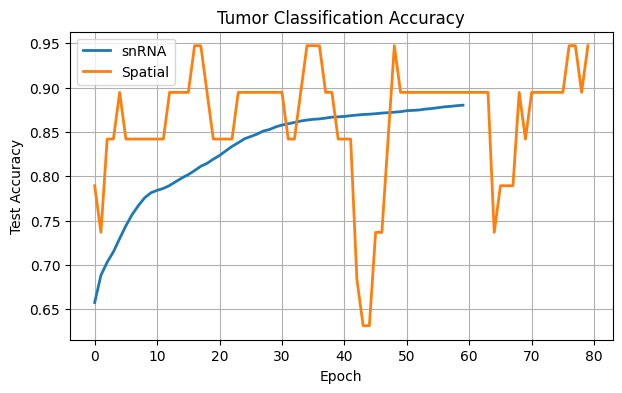

In [169]:
plt.figure(figsize=(7,4))
plt.plot(hist_sn["test_acc"], label="snRNA", linewidth=2)
plt.plot(hist_sp["test_acc"], label="Spatial", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Tumor Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()


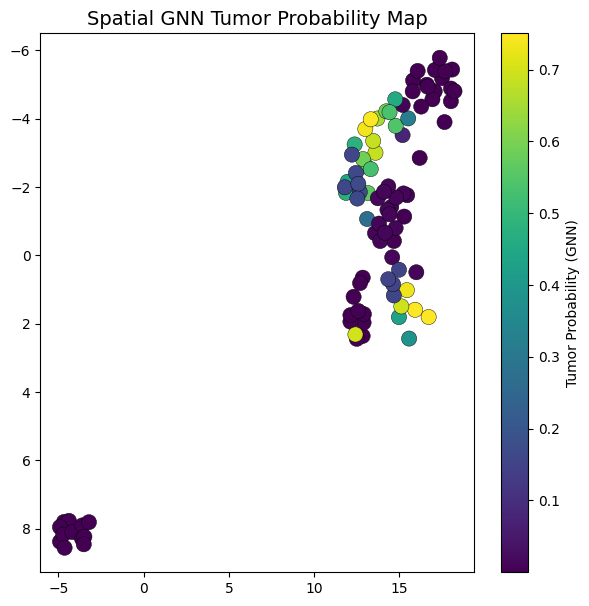

In [170]:
device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    logits = model_sp(
        spatial_graph.x.to(device),
        spatial_graph.edge_index.to(device)
    )
    tumor_prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

pos = spatial_graph.pos.cpu().numpy()

plt.figure(figsize=(7,7))
plt.scatter(
    pos[:, 0],
    pos[:, 1],
    c=tumor_prob,
    cmap="viridis",
    s=120,
    edgecolors="black",
    linewidth=0.3
)
plt.colorbar(label="Tumor Probability (GNN)")
plt.title("Spatial GNN Tumor Probability Map", fontsize=14)
plt.gca().invert_yaxis()
plt.show()


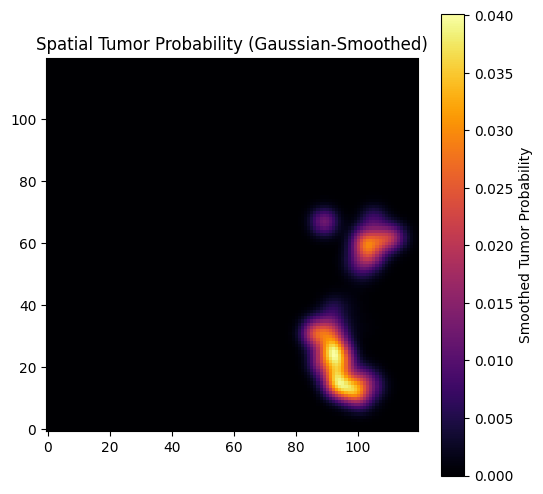

In [171]:
device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    out = model_sp(spatial_graph.x.to(device), spatial_graph.edge_index.to(device))
    tumor_prob = F.softmax(out, dim=1)[:,1].cpu().numpy()

coords = spatial_graph.pos.cpu().numpy()
x = coords[:,0]
y = coords[:,1]

x_scaled = (x - x.min()) / (x.max() - x.min())
y_scaled = (y - y.min()) / (y.max() - y.min())

grid_size = 120
grid = np.zeros((grid_size, grid_size))

for p, (xx, yy) in enumerate(zip(x_scaled, y_scaled)):
    gx = int(xx * (grid_size - 1))
    gy = int(yy * (grid_size - 1))
    grid[gy, gx] = tumor_prob[p]

grid_smooth = gaussian_filter(grid, sigma=3)

plt.figure(figsize=(6,6))
plt.imshow(grid_smooth, cmap="inferno", origin="lower")
plt.colorbar(label="Smoothed Tumor Probability")
plt.title("Spatial Tumor Probability (Gaussian-Smoothed)")
plt.show()
